# Temperature-Dependent MOSFET On-Resistance

This notebook documents the temperature dependence of the IRFZ44N MOSFET on-resistance and shows how this affects conduction loss and total MOSFET loss.

The resulting temperature-dependent Rds(on) relationship is used by the final electro-thermal coupling model.

## 1. Method and Assumptions

The datasheet maximum on-resistance at **25°C** is used as the conservative reference:

**Rds(on, 25°C) = 0.0175 ohm**

Resistance at another junction temperature is estimated using:

`Rds(on, T) = Rds(on, 25°C) × normalised resistance factor`

The normalised factors are approximate values read from the IRFZ44N datasheet curve and are therefore treated as engineering estimates rather than exact tabulated manufacturer values.

The earlier **0.0139 ohm** value is retained only for direct analytical comparison with the LTspice model and is not used for this temperature-dependent conservative calculation.


## 2. Temperature-Dependent Rds(on) Data

The following code constructs the temperature-dependent resistance table used throughout the electro-thermal model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datasheet maximum Rds(on) at 25°C
rds_on_25 = 0.0175

# Approximate values read from the datasheet normalised curve
temperatures = np.array([
    25,
    50,
    75,
    100,
    125,
    150,
    175
])

normalised_factors = np.array([
    1.00,
    1.15,
    1.35,
    1.58,
    1.82,
    2.10,
    2.39
])

temperature_results = pd.DataFrame({
    "Junction temperature (°C)": temperatures,
    "Normalised Rds(on)": normalised_factors
})

temperature_results["Rds(on) (ohm)"] = (
    rds_on_25 * temperature_results["Normalised Rds(on)"]
)

temperature_results.round(5)

,Junction temperature (°C),Normalised Rds(on),Rds(on) (ohm)
0,25,1.00,0.01750
1,50,1.15,0.02012
2,75,1.35,0.02363
3,100,1.58,0.02765
4,125,1.82,0.03185
5,150,2.10,0.03675
6,175,2.39,0.04183


## 3. Rds(on) Against Junction Temperature


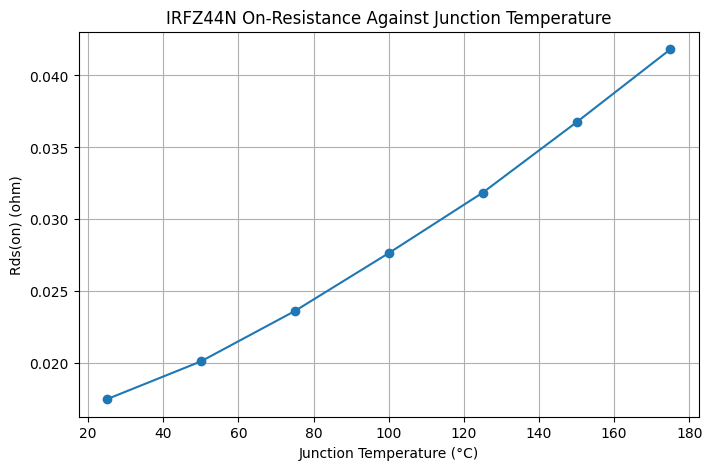

In [2]:
plt.figure(figsize=(8, 5))

plt.plot(
    temperature_results["Junction temperature (°C)"],
    temperature_results["Rds(on) (ohm)"],
    marker="o"
)

plt.xlabel("Junction Temperature (°C)")
plt.ylabel("Rds(on) (ohm)")
plt.title("IRFZ44N On-Resistance Against Junction Temperature")
plt.grid()

plt.show()

## 4. Effect on Conduction Loss

For this temperature-dependence demonstration, the electrical operating point is fixed at:

- Load current = **10 A**
- Duty cycle = **0.5**

Conduction loss is calculated using:

`Pcond = I² × Rds(on, Tj) × D`


In [3]:
current = 10.0
duty_cycle = 0.5

temperature_results["Conduction loss (W)"] = (
    current**2
    * temperature_results["Rds(on) (ohm)"]
    * duty_cycle
)

temperature_results.round(4)

,Junction temperature (°C),Normalised Rds(on),Rds(on) (ohm),Conduction loss (W)
0,25,1.00,0.0175,0.8750
1,50,1.15,0.0201,1.0062
2,75,1.35,0.0236,1.1813
3,100,1.58,0.0277,1.3825
4,125,1.82,0.0319,1.5925
5,150,2.10,0.0368,1.8375
6,175,2.39,0.0418,2.0913


## 5. Effect on Total MOSFET Loss

For this controlled comparison, switching loss is held constant at the 10 A nominal analytical value:

**Psw = 0.630 W**

This isolates the influence of increasing Rds(on) on conduction loss as junction temperature rises.


In [4]:
switching_loss = 0.630

temperature_results["Switching loss (W)"] = switching_loss

temperature_results["Total analytical loss (W)"] = (
    temperature_results["Conduction loss (W)"]
    + temperature_results["Switching loss (W)"]
)

temperature_results.round(4)

,Junction temperature (°C),Normalised Rds(on),Rds(on) (ohm),Conduction loss (W),Switching loss (W),Total analytical loss (W)
0,25,1.00,0.0175,0.8750,0.63,1.5050
1,50,1.15,0.0201,1.0062,0.63,1.6362
2,75,1.35,0.0236,1.1813,0.63,1.8113
3,100,1.58,0.0277,1.3825,0.63,2.0125
4,125,1.82,0.0319,1.5925,0.63,2.2225
5,150,2.10,0.0368,1.8375,0.63,2.4675
6,175,2.39,0.0418,2.0913,0.63,2.7213


## 6. Total MOSFET Loss Against Junction Temperature


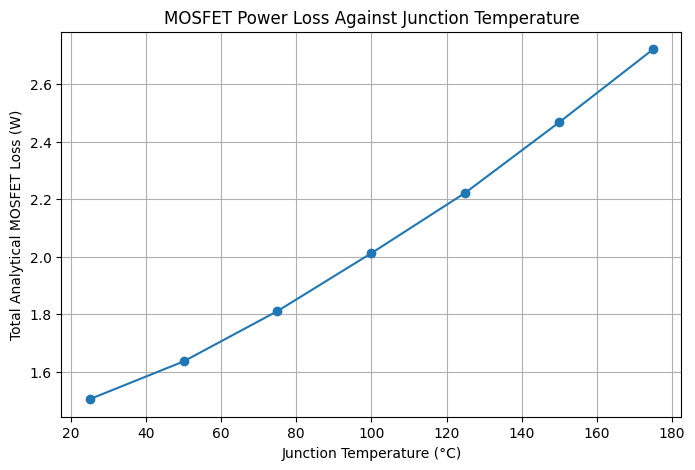

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    temperature_results["Junction temperature (°C)"],
    temperature_results["Total analytical loss (W)"],
    marker="o"
)

plt.xlabel("Junction Temperature (°C)")
plt.ylabel("Total Analytical MOSFET Loss (W)")
plt.title("MOSFET Power Loss Against Junction Temperature")
plt.grid()

plt.show()

## 7. Temperature-Dependence Interpretation

The datasheet-based estimate shows that IRFZ44N Rds(on) rises substantially with junction temperature.

Using the conservative **0.0175 ohm at 25°C** reference, Rds(on) increases to approximately **0.0418 ohm at 175°C**.

For the 10 A, 50% duty-cycle demonstration:

- Conduction loss increases from approximately **0.875 W at 25°C** to approximately **2.09 W at 175°C**.
- With switching loss held at **0.630 W**, total analytical MOSFET loss rises from approximately **1.505 W** to approximately **2.72 W**.

This produces **positive electro-thermal feedback**:

`higher Tj → higher Rds(on) → higher conduction loss → more heat → higher Tj`

The final coupled model therefore updates Rds(on), MOSFET loss and junction temperature iteratively until the junction-temperature change falls below the selected convergence criterion.

The **175°C** point is the absolute MOSFET junction-temperature limit and is used only as an extreme boundary condition, not as a recommended operating temperature.

## 8. Model Handoff

The temperature-dependent Rds(on) relationship defined here is used in `../../coupled-simulation/electro_thermal_coupling_cleaned.ipynb`.

The coupled model applies it to the electrically derived **5 A, 10 A and 20 A** operating points. The separately imposed **10 W and 15 W thermal-stress cases** are not part of this electrical feedback calculation.
